In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn

import os
import zipfile
import urllib.request

In [3]:
data_dir = "../data"

## Data downloading

In [4]:
movies_data_dir_path = os.path.join(data_dir, "ml-1m")
zip_path = os.path.join(data_dir, "ml-1m.zip")
data_url = "http://files.grouplens.org/datasets/movielens/ml-1m.zip"

if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    
if not os.path.exists(movies_data_dir_path):
    print("there is no data. downloading")
    
    urllib.request.urlretrieve(data_url, zip_path)
    
    with zipfile.ZipFile(zip_path, "r") as zip_data:
        zip_data.extractall(data_dir)
        
        os.remove(zip_path)
        print(f'data is downloaded and extracted to {movies_data_dir_path}')
else:
    print(f'data already exists in {movies_data_dir_path}')

data already exists in ../data/ml-1m


In [5]:
ratings_path  = os.path.join(movies_data_dir_path, 'ratings.dat')
col_names = ['user_id', 'item_id', 'rating', 'timestamp']

df = pd.read_csv(ratings_path, sep='::', engine='python', names=col_names)
df.head()

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


## EDA

In [6]:
print(f'interactions quantity: {df.shape}')
print(f'unique users: {len(df['user_id'].unique())}')
print(f'unique items: {len(df['item_id'].unique())}')

interactions quantity: (1000209, 4)
unique users: 6040
unique items: 3706


In [7]:
def rating_quantity(main_data, group_by_col, func_col, func):
    group_df = main_data.groupby(group_by_col).agg(
        quantity=(func_col, func)
    ).reset_index()
    
    group_df = group_df.rename(columns={
        'quantity':f'{func_col}_quantity'
    })
    
    group_df = group_df.sort_values(by=f'{func_col}_quantity', ascending=False)
    
    return group_df

user_rating = rating_quantity(df, 'user_id', 'rating', 'size')
item_rating = rating_quantity(df, 'item_id', 'rating', 'size')

In [8]:
item_rating.head(10)

,item_id,rating_quantity
2651,2858,3428
253,260,2991
1106,1196,2990
1120,1210,2883
466,480,2672
1848,2028,2653
575,589,2649
2374,2571,2590
1178,1270,2583
579,593,2578


In [9]:
user_rating.head(10)

,user_id,rating_quantity
4168,4169,2314
1679,1680,1850
4276,4277,1743
1940,1941,1595
1180,1181,1521
888,889,1518
3617,3618,1344
2062,2063,1323
1149,1150,1302
1014,1015,1286


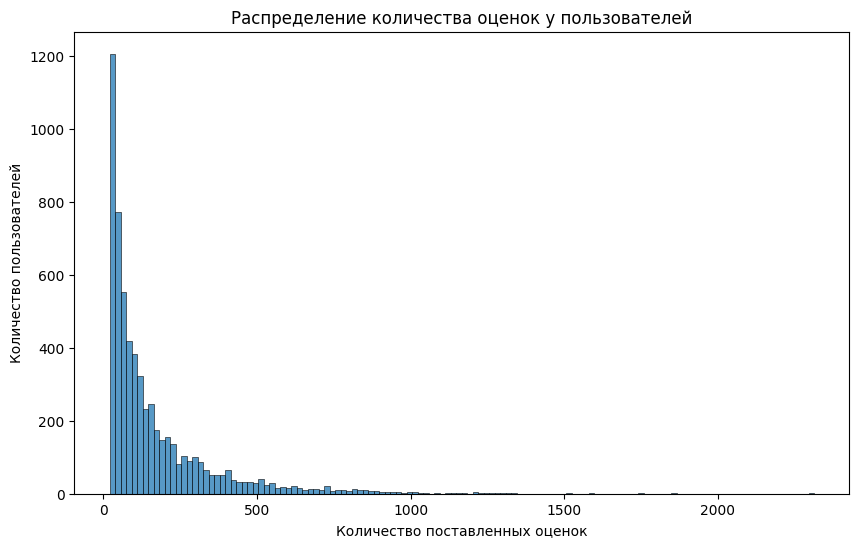

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_rating,
    x='rating_quantity'
)

plt.title('Распределение количества оценок у пользователей')
plt.xlabel('Количество поставленных оценок')
plt.ylabel('Количество пользователей')
plt.show()

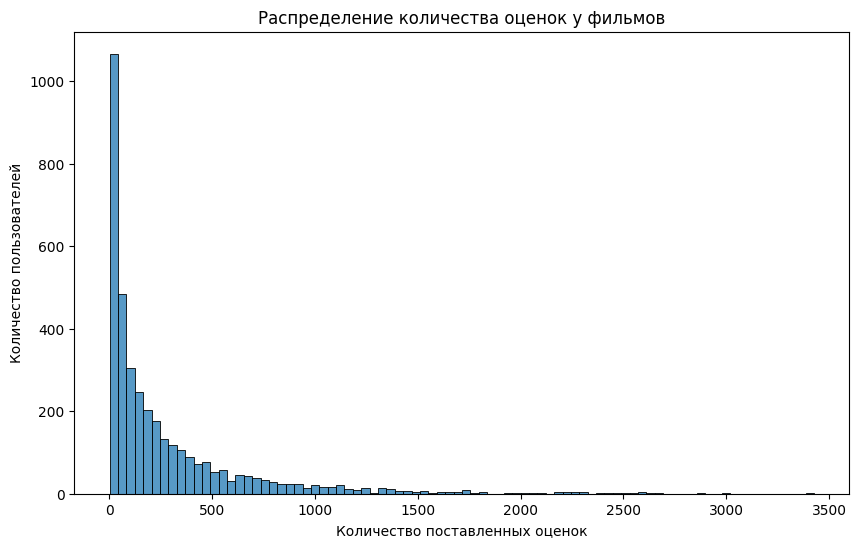

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=item_rating,
    x='rating_quantity'
)

plt.title('Распределение количества оценок у фильмов')
plt.xlabel('Количество поставленных оценок')
plt.ylabel('Количество пользователей')
plt.show()

In [12]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
min_date = df['timestamp'].min()

df['last_watch_dt'] = df['timestamp'] - min_date
df['last_watch_dt'] = df['last_watch_dt'].apply(lambda x: int(str(x).split()[0]))
df = df.drop(columns='timestamp')

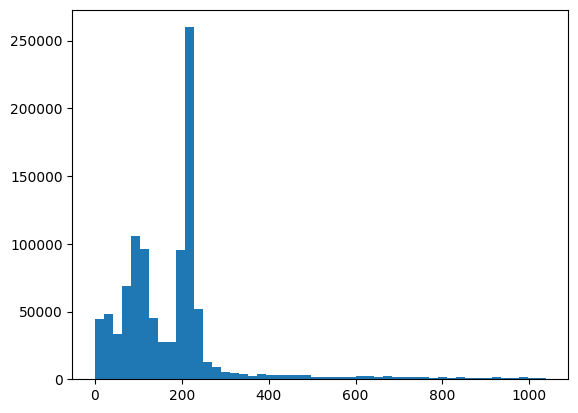

In [13]:
df['last_watch_dt'].hist(bins=50, grid=False)
plt.show()

## Filtering data

In [ ]:
active_users = user_rating.loc[user_rating['rating_quantity'] >= 10, 'user_id'].unique()
active_films = item_rating.loc[item_rating['rating_quantity'] >= 10, 'item_id'].unique()

mask = (df['user_id'].isin(active_users)) & (df['item_id'].isin(active_films))
filtered_df = df[mask].copy()

In [15]:
print(f'old shape: {df.shape}')
print(f'filtered df shape: {filtered_df.shape}')

old shape: (1000209, 4)
filtered df shape: (998539, 4)


## Train test split

In [17]:
max_date = filtered_df['last_watch_dt'].max()
log_size = 30

cut_off_date = max_date - log_size 

In [ ]:
train_df = filtered_df[filtered_df['last_watch_dt'] < cut_off_date].copy()
test_df = filtered_df[filtered_df['last_watch_dt'] >= cut_off_date].copy()

In [19]:
assert train_df['last_watch_dt'].max() < test_df['last_watch_dt'].min(), 'wrong cut off date'

In [20]:
train_users_ids = train_df['user_id'].unique()
train_item_ids = train_df['item_id'].unique()

test_df = test_df[test_df['user_id'].isin(train_users_ids)].copy()
test_df = test_df[test_df['item_id'].isin(train_item_ids)].copy()

In [30]:
assert set(test_df['user_id'].unique()).issubset(set(train_df['user_id'].unique())), 'wrong user ids in test df'
assert set(test_df['item_id'].unique()).issubset(set(train_df['item_id'].unique())), 'wrong item ids in test df'

## Modeling